In [2]:
import os
from contextlib import contextmanager

import joblib
from joblib import Parallel, delayed, parallel_backend
from tqdm.auto import tqdm

from pathlib import Path
from typing import Iterable, Literal

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import rankdata

from HPC_2P_analysis.utils.config import (
    get_itr_index,
    get_one_index,
    get_data_track_type,
    get_data_behavior_type,
    resolve_type_patterns,
    index_to_type,
)

from HPC_2P_analysis.utils.loadData import (
    load_raw_data,
    load_screen_data,
)

from HPC_2P_analysis.utils.processData import (
    align_track_hpc,
)


GeneralizationCorrMethod = Literal["pearson", "spearman"]
ShiftSummary = Literal["median", "mean"]
PermutationAlternative = Literal["two-sided", "greater", "less"]

In [3]:
@contextmanager
def tqdm_joblib(tqdm_object):
    old_callback = joblib.parallel.BatchCompletionCallBack

    class TqdmBatchCompletionCallback(old_callback):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    joblib.parallel.BatchCompletionCallBack = (
        TqdmBatchCompletionCallback
    )

    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()

In [4]:
def load_position_generalization_data(
    file_path: str | Path,
    *,
    screen_mode: str = "masked",
) -> dict:
    """读取位置泛化分析所需的数据。"""
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()

    if suffix == ".mat":
        return load_raw_data(file_path)

    if suffix in {".pkl", ".pickle"}:
        return load_screen_data(
            file_path,
            screen_mode=screen_mode,
        )

    raise ValueError(
        f"Unsupported file suffix: {suffix}. "
        "Expected .mat, .pkl, or .pickle."
    )


def _pg_as_tuple(x) -> tuple:
    """将字符串或可迭代对象统一转换为 tuple。"""
    if x is None:
        return ("*",)

    if isinstance(x, str):
        return (x,)

    return tuple(x)


def _resolve_pg_tracks(
    data: dict,
    ana_tt: Iterable[str],
) -> list[str]:
    """根据数据中真实存在的 track type 解析 ana_tt。"""
    track_type = get_data_track_type(data)

    selected_tracks = resolve_type_patterns(
        _pg_as_tuple(ana_tt),
        track_type,
    )

    if not selected_tracks:
        raise ValueError(
            "No track types matched ana_tt. "
            f"Requested={tuple(ana_tt)}, "
            f"available={track_type}."
        )

    return selected_tracks


def _collect_correct_noreward_trials(
    data: dict,
    *,
    selected_tracks: list[str],
    source_key: str = "smooth_firing",
    correct_behavior: str = "Correct",
    noreward_behavior: str = "NoReward",
) -> dict[str, dict[str, np.ndarray]]:
    """
    分别收集每条 track 的 Correct 与 NoReward trials。

    每个数组形状：
        (n_neuron, n_trial, n_position)
    """
    if source_key not in data:
        raise KeyError(
            f"data does not contain {source_key!r}."
        )

    available_behaviors = get_data_behavior_type(data)

    for behavior in (correct_behavior, noreward_behavior):
        if behavior not in available_behaviors:
            raise ValueError(
                f"{behavior!r} is unavailable. "
                f"Available behaviors: {available_behaviors}"
            )

    track_data: dict[str, dict[str, np.ndarray]] = {}

    expected_n_neuron: int | None = None
    expected_n_position: int | None = None

    for track_name in selected_tracks:
        correct_tt, correct_bt = get_one_index(
            data,
            track_name,
            correct_behavior,
        )

        noreward_tt, noreward_bt = get_one_index(
            data,
            track_name,
            noreward_behavior,
        )

        correct_fr = data[source_key][correct_tt, correct_bt]
        noreward_fr = data[source_key][noreward_tt, noreward_bt]

        if correct_fr is None:
            raise ValueError(
                f"No {correct_behavior} firing data for "
                f"track {track_name!r}."
            )

        if noreward_fr is None:
            raise ValueError(
                f"No {noreward_behavior} firing data for "
                f"track {track_name!r}."
            )

        correct_fr = np.asarray(correct_fr, dtype=float)
        noreward_fr = np.asarray(noreward_fr, dtype=float)

        if correct_fr.ndim != 3:
            raise ValueError(
                f"{track_name} | {correct_behavior} must be 3D, "
                f"got shape {correct_fr.shape}."
            )

        if noreward_fr.ndim != 3:
            raise ValueError(
                f"{track_name} | {noreward_behavior} must be 3D, "
                f"got shape {noreward_fr.shape}."
            )

        n_neuron, n_correct, n_position = correct_fr.shape
        (
            n_neuron_noreward,
            n_noreward,
            n_position_noreward,
        ) = noreward_fr.shape

        if n_correct < 2:
            raise ValueError(
                f"{track_name} has only {n_correct} Correct "
                "trial(s). At least 2 are required."
            )

        if n_noreward < 1:
            raise ValueError(
                f"{track_name} has no NoReward trials."
            )

        if n_neuron_noreward != n_neuron:
            raise ValueError(
                f"Neuron mismatch in {track_name}: "
                f"Correct={n_neuron}, "
                f"NoReward={n_neuron_noreward}."
            )

        if n_position_noreward != n_position:
            raise ValueError(
                f"Position mismatch in {track_name}: "
                f"Correct={n_position}, "
                f"NoReward={n_position_noreward}."
            )

        if expected_n_neuron is None:
            expected_n_neuron = n_neuron
            expected_n_position = n_position

        elif (
            n_neuron != expected_n_neuron
            or n_position != expected_n_position
        ):
            raise ValueError(
                "Selected tracks have inconsistent neuron "
                "or position dimensions."
            )

        track_data[track_name] = {
            "Correct": correct_fr,
            "NoReward": noreward_fr,
        }

    return track_data


def prepare_position_generalization_data(
    data: dict,
    *,
    ana_tt: Iterable[str] = ("*",),
    source_key: str = "smooth_firing",
    correct_behavior: str = "Correct",
    noreward_behavior: str = "NoReward",
    gaussian_sigma: float = 2.0,
) -> tuple[
    dict,
    list[str],
    dict[str, dict[str, np.ndarray]],
]:
    """完成 track 对齐、track 选择与 trial 收集。"""
    aligned_data = align_track_hpc(
        dict(data),
        gaussian_sigma=gaussian_sigma,
    )

    selected_tracks = _resolve_pg_tracks(
        aligned_data,
        _pg_as_tuple(ana_tt),
    )

    track_data = _collect_correct_noreward_trials(
        aligned_data,
        selected_tracks=selected_tracks,
        source_key=source_key,
        correct_behavior=correct_behavior,
        noreward_behavior=noreward_behavior,
    )

    return aligned_data, selected_tracks, track_data

In [5]:
def _rank_columns(x: np.ndarray) -> np.ndarray:
    """对每个位置分别按照神经元活动进行 rank。"""
    out = np.empty_like(x, dtype=float)

    for col_idx in range(x.shape[1]):
        out[:, col_idx] = rankdata(
            x[:, col_idx],
            method="average",
        )

    return out


def population_position_correlation(
    reference_activity: np.ndarray,
    test_activity: np.ndarray,
    *,
    method: GeneralizationCorrMethod = "pearson",
) -> np.ndarray:
    """
    计算位置与位置之间的 population-vector correlation。

    Parameters
    ----------
    reference_activity:
        形状为 (n_neuron, n_reference_position)。

    test_activity:
        形状为 (n_neuron, n_test_position)。

    Returns
    -------
    corr:
        形状为 (n_reference_position, n_test_position)。

        corr[i, j] 表示：
        reference 第 i 个位置的 population vector
        与 test 第 j 个位置的 population vector
        在神经元维度上的相关性。
    """
    reference_activity = np.asarray(
        reference_activity,
        dtype=float,
    )

    test_activity = np.asarray(
        test_activity,
        dtype=float,
    )

    if reference_activity.ndim != 2:
        raise ValueError(
            "reference_activity must have shape "
            "(n_neuron, n_position)."
        )

    if test_activity.ndim != 2:
        raise ValueError(
            "test_activity must have shape "
            "(n_neuron, n_position)."
        )

    if reference_activity.shape[0] != test_activity.shape[0]:
        raise ValueError(
            "Reference and test must have the same "
            "number of neurons."
        )

    valid_neurons = (
        np.all(np.isfinite(reference_activity), axis=1)
        & np.all(np.isfinite(test_activity), axis=1)
    )

    x = reference_activity[valid_neurons]
    y = test_activity[valid_neurons]

    if x.shape[0] < 3:
        raise ValueError(
            f"Only {x.shape[0]} valid neurons remain. "
            "At least 3 are required."
        )

    if method == "spearman":
        x = _rank_columns(x)
        y = _rank_columns(y)

    elif method != "pearson":
        raise ValueError(
            "method must be 'pearson' or 'spearman'."
        )

    x_mean = np.mean(x, axis=0, keepdims=True)
    y_mean = np.mean(y, axis=0, keepdims=True)

    x_std = np.std(x, axis=0, ddof=1, keepdims=True)
    y_std = np.std(y, axis=0, ddof=1, keepdims=True)

    valid_x_position = np.squeeze(x_std > 0)
    valid_y_position = np.squeeze(y_std > 0)

    corr = np.full(
        (x.shape[1], y.shape[1]),
        np.nan,
        dtype=float,
    )

    if (
        not np.any(valid_x_position)
        or not np.any(valid_y_position)
    ):
        return corr

    xz = (
        x[:, valid_x_position]
        - x_mean[:, valid_x_position]
    ) / x_std[:, valid_x_position]

    yz = (
        y[:, valid_y_position]
        - y_mean[:, valid_y_position]
    ) / y_std[:, valid_y_position]

    valid_corr = (
        xz.T @ yz
    ) / (x.shape[0] - 1)

    corr[
        np.ix_(
            valid_x_position,
            valid_y_position,
        )
    ] = valid_corr

    return np.clip(corr, -1.0, 1.0)

In [6]:
def get_local_peak_shift(
    matrix: np.ndarray,
    *,
    max_shift_bins: int | None = 10,
) -> dict:
    """
    对每个 reference position，在对角线附近寻找最大相关峰。

    单个位置的 shift 定义为：

        peak comparison index - reference index

    单个位置的 shift 是整数 bin，但跨 repeat 取均值之后，
    最终 shift 可以是小数。
    """
    matrix = np.asarray(matrix, dtype=float)

    if matrix.ndim != 2:
        raise ValueError("matrix must be 2D.")

    if max_shift_bins is not None and max_shift_bins < 0:
        raise ValueError(
            "max_shift_bins must be non-negative or None."
        )

    n_reference, n_test = matrix.shape

    peak_position = np.full(
        n_reference,
        np.nan,
        dtype=float,
    )

    shift_bins = np.full(
        n_reference,
        np.nan,
        dtype=float,
    )

    for reference_idx in range(n_reference):
        if max_shift_bins is None:
            lo = 0
            hi = n_test

        else:
            lo = max(
                0,
                reference_idx - max_shift_bins,
            )

            hi = min(
                n_test,
                reference_idx + max_shift_bins + 1,
            )

        row = matrix[reference_idx, lo:hi]

        if row.size == 0 or np.all(np.isnan(row)):
            continue

        local_peak = int(np.nanargmax(row))
        test_idx = lo + local_peak

        peak_position[reference_idx] = test_idx
        shift_bins[reference_idx] = (
            test_idx - reference_idx
        )

    valid_shift = shift_bins[np.isfinite(shift_bins)]

    if valid_shift.size == 0:
        mean_shift = np.nan
        median_shift = np.nan

    else:
        mean_shift = float(np.mean(valid_shift))
        median_shift = float(np.median(valid_shift))

    return {
        "peak_position": peak_position,
        "shift_bins": shift_bins,
        "mean_shift_bins": mean_shift,
        "median_shift_bins": median_shift,
        "n_valid_positions": int(valid_shift.size),
    }


def _select_shift_summary(
    shift_result: dict,
    *,
    shift_summary: ShiftSummary,
) -> float:
    """
    将一张相关矩阵中不同 reference positions 的 shift
    汇总为一个数值。
    """
    if shift_summary == "median":
        return float(
            shift_result["median_shift_bins"]
        )

    if shift_summary == "mean":
        return float(
            shift_result["mean_shift_bins"]
        )

    raise ValueError(
        "shift_summary must be 'median' or 'mean'."
    )


def _summarize_repeat_values(
    values: np.ndarray,
) -> dict:
    """
    汇总不同 Correct split repeats 得到的数值。

    注意：
    这里的 SD 和 percentile range 仅表示结果对随机拆分
    Correct trials 的敏感性，不是独立样本置信区间。
    """
    values = np.asarray(values, dtype=float)
    valid = values[np.isfinite(values)]

    if valid.size == 0:
        return {
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "percentile_2_5": np.nan,
            "percentile_97_5": np.nan,
            "positive_fraction": np.nan,
            "negative_fraction": np.nan,
            "zero_fraction": np.nan,
            "n_valid": 0,
        }

    if valid.size > 1:
        std = float(np.std(valid, ddof=1))
    else:
        std = 0.0

    lower, upper = np.percentile(
        valid,
        [2.5, 97.5],
    )

    return {
        "mean": float(np.mean(valid)),
        "median": float(np.median(valid)),
        "std": std,
        "percentile_2_5": float(lower),
        "percentile_97_5": float(upper),
        "positive_fraction": float(np.mean(valid > 0)),
        "negative_fraction": float(np.mean(valid < 0)),
        "zero_fraction": float(np.mean(valid == 0)),
        "n_valid": int(valid.size),
    }

In [7]:
def _get_trial_counts(
    track_data: dict[str, dict[str, np.ndarray]],
    selected_tracks: list[str],
) -> dict:
    """记录每条 track 的 Correct 和 NoReward trial 数量。"""
    trial_counts = {}

    for track_name in selected_tracks:
        n_correct = track_data[
            track_name
        ]["Correct"].shape[1]

        n_noreward = track_data[
            track_name
        ]["NoReward"].shape[1]

        n_half = n_correct // 2

        trial_counts[track_name] = {
            "n_correct_total": int(n_correct),
            "n_correct_half": int(n_half),
            "n_correct_used": int(2 * n_half),
            "n_correct_dropped_if_odd": int(
                n_correct - 2 * n_half
            ),
            "n_noreward": int(n_noreward),
        }

    return trial_counts


def _compute_repeated_generalization_from_trials(
    track_data: dict[str, dict[str, np.ndarray]],
    *,
    selected_tracks: list[str],
    corr_method: GeneralizationCorrMethod,
    n_repeats: int,
    rng: np.random.Generator,
    max_shift_bins: int | None,
    shift_summary: ShiftSummary,
    store_matrices: bool,
) -> dict:
    """
    对给定 trial labels 运行 repeated split-half 分析。

    每个 repeat 内：

    1. 将 Correct trials 随机分成两半；
    2. 计算 Correct vs. Correct correlation matrix；
    3. 计算 Correct vs. NoReward correlation matrix；
    4. 分别提取 shift；
    5. 计算配对 relative shift：

           Correct-vs-NoReward shift
           - Correct-vs-Correct shift
    """
    if n_repeats < 1:
        raise ValueError(
            "n_repeats must be at least 1."
        )

    first_track = selected_tracks[0]

    n_position = track_data[
        first_track
    ]["Correct"].shape[2]

    if store_matrices:
        cc_matrices = np.full(
            (n_repeats, n_position, n_position),
            np.nan,
            dtype=float,
        )

        cn_matrices = np.full(
            (n_repeats, n_position, n_position),
            np.nan,
            dtype=float,
        )

    else:
        cc_matrices = None
        cn_matrices = None

    cc_shift_repeats = np.full(
        n_repeats,
        np.nan,
        dtype=float,
    )

    cn_shift_repeats = np.full(
        n_repeats,
        np.nan,
        dtype=float,
    )

    relative_shift_repeats = np.full(
        n_repeats,
        np.nan,
        dtype=float,
    )

    # NoReward 在每个 repeat 中不拆分，使用全部 trials。
    noreward_track_means = []

    for track_name in selected_tracks:
        noreward_fr = track_data[
            track_name
        ]["NoReward"]

        noreward_track_means.append(
            np.nanmean(
                noreward_fr,
                axis=1,
            )
        )

    # 多条 track 等权平均。
    noreward_mean = np.nanmean(
        np.stack(
            noreward_track_means,
            axis=0,
        ),
        axis=0,
    )

    for repeat_idx in range(n_repeats):
        correct_reference_track_means = []
        correct_comparison_track_means = []

        for track_name in selected_tracks:
            correct_fr = track_data[
                track_name
            ]["Correct"]

            n_correct = correct_fr.shape[1]
            n_half = n_correct // 2

            shuffled_idx = rng.permutation(
                n_correct
            )

            reference_idx = shuffled_idx[:n_half]

            comparison_idx = shuffled_idx[
                n_half:2 * n_half
            ]

            correct_reference_track_means.append(
                np.nanmean(
                    correct_fr[
                        :,
                        reference_idx,
                        :,
                    ],
                    axis=1,
                )
            )

            correct_comparison_track_means.append(
                np.nanmean(
                    correct_fr[
                        :,
                        comparison_idx,
                        :,
                    ],
                    axis=1,
                )
            )

        # 每条 track 等权。
        correct_reference_mean = np.nanmean(
            np.stack(
                correct_reference_track_means,
                axis=0,
            ),
            axis=0,
        )

        correct_comparison_mean = np.nanmean(
            np.stack(
                correct_comparison_track_means,
                axis=0,
            ),
            axis=0,
        )

        cc_matrix = population_position_correlation(
            correct_reference_mean,
            correct_comparison_mean,
            method=corr_method,
        )

        cn_matrix = population_position_correlation(
            correct_reference_mean,
            noreward_mean,
            method=corr_method,
        )

        if store_matrices:
            cc_matrices[repeat_idx] = cc_matrix
            cn_matrices[repeat_idx] = cn_matrix

        cc_shift_result = get_local_peak_shift(
            cc_matrix,
            max_shift_bins=max_shift_bins,
        )

        cn_shift_result = get_local_peak_shift(
            cn_matrix,
            max_shift_bins=max_shift_bins,
        )

        cc_shift = _select_shift_summary(
            cc_shift_result,
            shift_summary=shift_summary,
        )

        cn_shift = _select_shift_summary(
            cn_shift_result,
            shift_summary=shift_summary,
        )

        cc_shift_repeats[repeat_idx] = cc_shift
        cn_shift_repeats[repeat_idx] = cn_shift

        relative_shift_repeats[repeat_idx] = (
            cn_shift - cc_shift
        )

    return {
        "correct_correct_repeats": cc_matrices,
        "correct_noreward_repeats": cn_matrices,
        "correct_correct_shift_repeats": (
            cc_shift_repeats
        ),
        "correct_noreward_shift_repeats": (
            cn_shift_repeats
        ),
        "relative_shift_repeats": (
            relative_shift_repeats
        ),
        "correct_correct_shift_summary": (
            _summarize_repeat_values(
                cc_shift_repeats
            )
        ),
        "correct_noreward_shift_summary": (
            _summarize_repeat_values(
                cn_shift_repeats
            )
        ),
        "relative_shift_summary": (
            _summarize_repeat_values(
                relative_shift_repeats
            )
        ),
    }


def compute_position_generalization(
    data: dict,
    *,
    ana_tt: Iterable[str] = ("*",),
    correct_behavior: str = "Correct",
    noreward_behavior: str = "NoReward",
    source_key: str = "smooth_firing",
    gaussian_sigma: float = 2.0,
    corr_method: GeneralizationCorrMethod = "spearman",
    n_repeats: int = 100,
    max_shift_bins: int | None = 10,
    shift_summary: ShiftSummary = "median",
    random_state: int | None = 0,
) -> dict:
    """
    计算 repeated position-generalization matrix 与 shift。

    对第 r 个 repeat：

        ΔS_r =
            shift(Correct vs. NoReward)_r
            - shift(Correct vs. Correct)_r

    主要观测效应量：

        observed shift = mean_r(ΔS_r)

    repeats 只用于评估 Correct trial 随机拆分的稳定性，
    不作为独立生物学样本。
    """
    (
        aligned_data,
        selected_tracks,
        track_data,
    ) = prepare_position_generalization_data(
        data,
        ana_tt=ana_tt,
        source_key=source_key,
        correct_behavior=correct_behavior,
        noreward_behavior=noreward_behavior,
        gaussian_sigma=gaussian_sigma,
    )

    rng = np.random.default_rng(
        random_state
    )

    repeated = (
        _compute_repeated_generalization_from_trials(
            track_data,
            selected_tracks=selected_tracks,
            corr_method=corr_method,
            n_repeats=n_repeats,
            rng=rng,
            max_shift_bins=max_shift_bins,
            shift_summary=shift_summary,
            store_matrices=True,
        )
    )

    cc_matrices = repeated[
        "correct_correct_repeats"
    ]

    cn_matrices = repeated[
        "correct_noreward_repeats"
    ]

    cc_mean = np.nanmean(
        cc_matrices,
        axis=0,
    )

    cn_mean = np.nanmean(
        cn_matrices,
        axis=0,
    )

    first_track = selected_tracks[0]

    n_neuron = track_data[
        first_track
    ]["Correct"].shape[0]

    n_position = track_data[
        first_track
    ]["Correct"].shape[2]

    result = {
        "correct_correct": cc_mean,
        "correct_noreward": cn_mean,
        "difference": cn_mean - cc_mean,

        "correct_correct_std": np.nanstd(
            cc_matrices,
            axis=0,
            ddof=0,
        ),

        "correct_noreward_std": np.nanstd(
            cn_matrices,
            axis=0,
            ddof=0,
        ),

        **repeated,

        "observed_relative_shift_bins": repeated[
            "relative_shift_summary"
        ]["mean"],

        "selected_tracks": selected_tracks,

        "trial_counts": _get_trial_counts(
            track_data,
            selected_tracks,
        ),

        "n_neuron": int(n_neuron),
        "n_position": int(n_position),
        "n_repeats": int(n_repeats),
        "random_state": random_state,
        "corr_method": corr_method,
        "gaussian_sigma": gaussian_sigma,
        "source_key": source_key,
        "max_shift_bins": max_shift_bins,
        "shift_summary": shift_summary,

        "file_info": dict(
            aligned_data.get(
                "file_info",
                {},
            )
        ),

        # permutation test 需要原始 trial arrays。
        # 如果之后保存 result 且担心文件过大，可以删除该字段。
        "_track_data": track_data,
    }

    return result

In [8]:
def _permute_behavior_labels_within_track(
    track_data: dict[str, dict[str, np.ndarray]],
    *,
    selected_tracks: list[str],
    rng: np.random.Generator,
) -> dict[str, dict[str, np.ndarray]]:
    """
    在每条 track 内置换 Correct/NoReward labels。

    保持：
    - 原始 Correct trial 数；
    - 原始 NoReward trial 数；
    - 每条 track 独立置换。
    """
    permuted_track_data = {}

    for track_name in selected_tracks:
        correct_fr = track_data[
            track_name
        ]["Correct"]

        noreward_fr = track_data[
            track_name
        ]["NoReward"]

        n_correct = correct_fr.shape[1]
        n_noreward = noreward_fr.shape[1]

        pooled = np.concatenate(
            [
                correct_fr,
                noreward_fr,
            ],
            axis=1,
        )

        permuted_idx = rng.permutation(
            n_correct + n_noreward
        )

        pseudo_correct_idx = permuted_idx[
            :n_correct
        ]

        pseudo_noreward_idx = permuted_idx[
            n_correct:n_correct + n_noreward
        ]

        permuted_track_data[track_name] = {
            "Correct": pooled[
                :,
                pseudo_correct_idx,
                :,
            ],
            "NoReward": pooled[
                :,
                pseudo_noreward_idx,
                :,
            ],
        }

    return permuted_track_data


def _monte_carlo_permutation_pvalue(
    observed: float,
    null_distribution: np.ndarray,
    *,
    alternative: PermutationAlternative,
) -> float:
    """
    计算带有限样本修正的 Monte Carlo permutation p-value。
    """
    null_distribution = np.asarray(
        null_distribution,
        dtype=float,
    )

    null_distribution = null_distribution[
        np.isfinite(null_distribution)
    ]

    if not np.isfinite(observed):
        return np.nan

    if null_distribution.size == 0:
        return np.nan

    p_greater = (
        np.sum(
            null_distribution >= observed
        )
        + 1
    ) / (null_distribution.size + 1)

    p_less = (
        np.sum(
            null_distribution <= observed
        )
        + 1
    ) / (null_distribution.size + 1)

    if alternative == "two-sided":
        return float(
            min(
                1.0,
                2.0 * min(
                    p_less,
                    p_greater,
                ),
            )
        )

    if alternative == "greater":
        return float(p_greater)

    if alternative == "less":
        return float(p_less)

    raise ValueError(
        "alternative must be 'two-sided', "
        "'greater', or 'less'."
    )


def _run_one_relative_shift_permutation(
    seed: int,
    *,
    track_data: dict[str, dict[str, np.ndarray]],
    selected_tracks: list[str],
    corr_method: GeneralizationCorrMethod,
    n_repeats_per_permutation: int,
    max_shift_bins: int | None,
    shift_summary: ShiftSummary,
) -> float:
    """
    执行一次完整的 trial-label permutation。

    每个 worker 负责：

    1. 在每条 track 内置换 Correct/NoReward 标签；
    2. 对 pseudo-Correct trials 做 repeated split-half；
    3. 计算该 permutation 的平均 relative shift。

    Parameters
    ----------
    seed:
        当前 permutation 独立使用的随机种子。

    Returns
    -------
    float
        当前 permutation 的平均 relative shift，单位为 bin。
    """
    rng = np.random.default_rng(seed)

    permuted_track_data = (
        _permute_behavior_labels_within_track(
            track_data,
            selected_tracks=selected_tracks,
            rng=rng,
        )
    )

    permuted_result = (
        _compute_repeated_generalization_from_trials(
            permuted_track_data,
            selected_tracks=selected_tracks,
            corr_method=corr_method,
            n_repeats=n_repeats_per_permutation,
            rng=rng,
            max_shift_bins=max_shift_bins,
            shift_summary=shift_summary,
            store_matrices=False,
        )
    )

    return float(
        permuted_result[
            "relative_shift_summary"
        ]["mean"]
    )


def permutation_test_relative_shift(
    result: dict,
    *,
    n_permutations: int = 1000,
    n_repeats_per_permutation: int = 10,
    alternative: PermutationAlternative = "two-sided",
    random_state: int | None = 1,
    n_jobs: int | None = 8,
    show_progress: bool = True,
    batch_size: int | str = 1,
) -> dict:
    """
    使用多进程 trial-label permutation test 检验 relative shift。

    并行层级
    --------
    一个进程负责一个完整 permutation。

    每个 permutation 内部：

    1. 在每条 track 内置换 Correct/NoReward 标签；
    2. 保持两类 trial 的原始数量；
    3. 对 pseudo-Correct 运行 repeated split-half；
    4. 得到一个平均 relative shift；
    5. 所有 permutation 组成零分布。

    Parameters
    ----------
    result:
        compute_position_generalization() 的返回结果。

    n_permutations:
        标签置换次数。它决定 p 值分辨率。

    n_repeats_per_permutation:
        每个置换数据集内部拆分 pseudo-Correct 的次数。

    alternative:
        "two-sided"、"greater" 或 "less"。

    random_state:
        主随机种子。

    n_jobs:
        并行进程数。

        - 8：使用 8 个进程；
        - -1：使用所有可见 CPU 核心；
        - 1：退化为单进程。

    show_progress:
        是否显示 tqdm 进度条和预计剩余时间。

    batch_size:
        joblib 每批提交的 permutation 数。

        设为 1 时进度更新最及时；
        设为 "auto" 时调度开销通常更低。

    Returns
    -------
    dict
        置换零分布、p 值及相关统计量。
    """
    if n_permutations < 1:
        raise ValueError(
            "n_permutations must be at least 1."
        )

    if n_repeats_per_permutation < 1:
        raise ValueError(
            "n_repeats_per_permutation must be at least 1."
        )

    if n_jobs == 0:
        raise ValueError(
            "n_jobs cannot be 0."
        )

    if "_track_data" not in result:
        raise KeyError(
            "result does not contain '_track_data'. "
            "Run compute_position_generalization() first."
        )

    if n_jobs is None:
        visible_cpu_count = os.cpu_count() or 1

        # 默认最多使用 8 个进程，并尽量为系统保留一个核心。
        n_jobs = max(
            1,
            min(
                8,
                visible_cpu_count - 1,
            ),
        )

    observed = float(
        result[
            "observed_relative_shift_bins"
        ]
    )

    selected_tracks = list(
        result["selected_tracks"]
    )

    track_data = result["_track_data"]

    # 为每个 permutation 生成独立且可重复的随机种子。
    master_seed = np.random.SeedSequence(
        random_state
    )

    child_seed_sequences = master_seed.spawn(
        n_permutations
    )

    permutation_seeds = [
        int(
            child_seed.generate_state(
                1,
                dtype=np.uint64,
            )[0]
        )
        for child_seed in child_seed_sequences
    ]

    def run_parallel_tasks() -> list[float]:
        return Parallel(
            n_jobs=n_jobs,
            backend="loky",
            batch_size=batch_size,
            pre_dispatch="2*n_jobs",

            # 较大的 NumPy 数组通过临时 memory map 共享，
            # 减少每个进程重复复制数组的内存开销。
            max_nbytes="10M",
            mmap_mode="r",

            verbose=0,
        )(
            delayed(
                _run_one_relative_shift_permutation
            )(
                seed,
                track_data=track_data,
                selected_tracks=selected_tracks,
                corr_method=result[
                    "corr_method"
                ],
                n_repeats_per_permutation=(
                    n_repeats_per_permutation
                ),
                max_shift_bins=result[
                    "max_shift_bins"
                ],
                shift_summary=result[
                    "shift_summary"
                ],
            )
            for seed in permutation_seeds
        )

    # 防止每个进程内部的 BLAS/OpenMP 再使用多个线程，
    # 避免 8 个进程 × 每进程若干线程造成严重过度并行。
    with parallel_backend(
        "loky",
        inner_max_num_threads=1,
    ):
        if show_progress:
            with tqdm_joblib(
                tqdm(
                    total=n_permutations,
                    desc=(
                        f"Permutation test "
                        f"({n_jobs} processes)"
                    ),
                    unit="perm",
                    dynamic_ncols=True,
                    mininterval=0.5,
                )
            ):
                null_values = run_parallel_tasks()

        else:
            null_values = run_parallel_tasks()

    null_distribution = np.asarray(
        null_values,
        dtype=float,
    )

    p_value = (
        _monte_carlo_permutation_pvalue(
            observed,
            null_distribution,
            alternative=alternative,
        )
    )

    null_valid = null_distribution[
        np.isfinite(null_distribution)
    ]

    if null_valid.size == 0:
        null_mean = np.nan
        null_std = np.nan
        null_interval = (
            np.nan,
            np.nan,
        )

    else:
        null_mean = float(
            np.mean(null_valid)
        )

        if null_valid.size > 1:
            null_std = float(
                np.std(
                    null_valid,
                    ddof=1,
                )
            )
        else:
            null_std = 0.0

        null_interval_array = np.percentile(
            null_valid,
            [2.5, 97.5],
        )

        null_interval = (
            float(null_interval_array[0]),
            float(null_interval_array[1]),
        )

    permutation_result = {
        "observed_relative_shift_bins": observed,
        "null_distribution_bins": null_distribution,
        "p_value": p_value,
        "alternative": alternative,
        "n_permutations": int(
            n_permutations
        ),
        "n_repeats_per_permutation": int(
            n_repeats_per_permutation
        ),
        "n_jobs": int(n_jobs),
        "null_mean_bins": null_mean,
        "null_std_bins": null_std,
        "null_percentile_interval_bins": (
            null_interval
        ),
        "random_state": random_state,
    }

    result["permutation_test"] = (
        permutation_result
    )

    return permutation_result

In [9]:
def plot_position_generalization(
    result: dict,
    *,
    space_unit: float = 2.0,
    position_offset_bins: float = 0.0,
    show_difference: bool = True,
    show_peak_ridge: bool = True,
    cmap: str = "viridis",
    difference_cmap: str = "coolwarm",
    corr_limits: tuple[float, float] | None = None,
    figsize=None,
    title_fontsize: int = 13,
    axis_label_fontsize: int = 12,
    tick_fontsize: int = 10,
):
    """
    绘制跨 repeats 平均后的 generalization matrices。

    图中使用：
    - Correct vs. Correct
    - Correct vs. NoReward

    不再显示 A/B。
    """
    cc = np.asarray(
        result["correct_correct"],
        dtype=float,
    )

    cn = np.asarray(
        result["correct_noreward"],
        dtype=float,
    )

    diff = np.asarray(
        result["difference"],
        dtype=float,
    )

    n_position = cc.shape[0]

    positions = (
        np.arange(n_position)
        - position_offset_bins
    ) * space_unit

    half_step = space_unit / 2.0

    extent = [
        positions[0] - half_step,
        positions[-1] + half_step,
        positions[0] - half_step,
        positions[-1] + half_step,
    ]

    if corr_limits is None:
        combined_values = np.concatenate(
            [
                cc[np.isfinite(cc)],
                cn[np.isfinite(cn)],
            ]
        )

        if combined_values.size == 0:
            vmin, vmax = -1.0, 1.0

        else:
            vmin = max(
                -1.0,
                float(
                    np.nanpercentile(
                        combined_values,
                        2,
                    )
                ),
            )

            vmax = min(
                1.0,
                float(
                    np.nanpercentile(
                        combined_values,
                        98,
                    )
                ),
            )

            if vmax <= vmin:
                vmin, vmax = -1.0, 1.0

    else:
        vmin, vmax = corr_limits

    finite_diff = diff[
        np.isfinite(diff)
    ]

    if finite_diff.size == 0:
        diff_abs = 1.0

    else:
        diff_abs = float(
            np.max(
                np.abs(finite_diff)
            )
        )

        if diff_abs == 0:
            diff_abs = 1.0

    # 白色 ridge 仍然绘制在平均矩阵上。
    cc_matrix_shift = get_local_peak_shift(
        cc,
        max_shift_bins=result[
            "max_shift_bins"
        ],
    )

    cn_matrix_shift = get_local_peak_shift(
        cn,
        max_shift_bins=result[
            "max_shift_bins"
        ],
    )

    n_panels = (
        3 if show_difference else 2
    )

    if figsize is None:
        figsize = (
            15.0 if show_difference else 10.5,
            4.5,
        )

    fig, axes = plt.subplots(
        1,
        n_panels,
        figsize=figsize,
        squeeze=False,
    )

    axes = axes.ravel()

    cc_repeat_mean_cm = (
        result[
            "correct_correct_shift_summary"
        ]["mean"]
        * space_unit
    )

    cn_repeat_mean_cm = (
        result[
            "correct_noreward_shift_summary"
        ]["mean"]
        * space_unit
    )

    matrices = [
        cc,
        cn,
    ]

    titles = [
        (
            "Correct vs. Correct\n"
            f"mean repeat shift = "
            f"{cc_repeat_mean_cm:.2f} cm"
        ),
        (
            "Correct vs. NoReward\n"
            f"mean repeat shift = "
            f"{cn_repeat_mean_cm:.2f} cm"
        ),
    ]

    matrix_shifts = [
        cc_matrix_shift,
        cn_matrix_shift,
    ]

    for (
        ax,
        matrix,
        title,
        shift_result,
    ) in zip(
        axes[:2],
        matrices,
        titles,
        matrix_shifts,
    ):
        image = ax.imshow(
            matrix,
            origin="lower",
            aspect="auto",
            extent=extent,
            interpolation="nearest",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        # Identity diagonal。
        ax.plot(
            positions,
            positions,
            linestyle="--",
            linewidth=1.0,
            color="black",
            alpha=0.75,
        )

        if show_peak_ridge:
            valid = np.isfinite(
                shift_result[
                    "peak_position"
                ]
            )

            peak_x = (
                shift_result[
                    "peak_position"
                ][valid]
                - position_offset_bins
            ) * space_unit

            peak_y = positions[valid]

            ax.plot(
                peak_x,
                peak_y,
                color="white",
                linewidth=1.4,
                alpha=0.9,
            )

        ax.set_title(
            title,
            fontsize=title_fontsize,
            pad=10,
        )

        ax.set_xlabel(
            "Comparison position (cm)",
            fontsize=axis_label_fontsize,
        )

        ax.tick_params(
            axis="both",
            labelsize=tick_fontsize,
        )

        fig.colorbar(
            image,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            label=(
                f"{result['corr_method'].capitalize()} "
                "correlation"
            ),
        )

    axes[0].set_ylabel(
        "Correct reference position (cm)",
        fontsize=axis_label_fontsize,
    )

    if show_difference:
        ax = axes[2]

        image = ax.imshow(
            diff,
            origin="lower",
            aspect="auto",
            extent=extent,
            interpolation="nearest",
            cmap=difference_cmap,
            vmin=-diff_abs,
            vmax=diff_abs,
        )

        ax.plot(
            positions,
            positions,
            linestyle="--",
            linewidth=1.0,
            color="black",
            alpha=0.75,
        )

        relative_shift_cm = (
            result[
                "observed_relative_shift_bins"
            ]
            * space_unit
        )

        ax.set_title(
            (
                "NoReward − Correct baseline\n"
                f"mean relative shift = "
                f"{relative_shift_cm:.2f} cm"
            ),
            fontsize=title_fontsize,
            pad=10,
        )

        ax.set_xlabel(
            "Comparison position (cm)",
            fontsize=axis_label_fontsize,
        )

        ax.tick_params(
            axis="both",
            labelsize=tick_fontsize,
        )

        fig.colorbar(
            image,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            label="Correlation difference",
        )

    file_info = result.get(
        "file_info",
        {},
    )

    fig.suptitle(
        (
            f"{file_info.get('mouse_id', 'NA')} | "
            f"{file_info.get('task_type', 'NA')} | "
            f"reward="
            f"{file_info.get('reward_mode', 'NA')} | "
            f"tracks="
            f"{','.join(result['selected_tracks'])}"
        ),
        fontsize=14,
        y=1.03,
    )

    fig.tight_layout()
    plt.show()

    return fig, axes

In [10]:
def plot_relative_shift_permutation(
    result: dict,
    *,
    space_unit: float = 2.0,
    bins: int = 30,
    figsize: tuple[float, float] = (6.5, 4.5),
):
    """
    绘制 trial-label permutation null distribution
    与真实 relative shift。
    """
    if "permutation_test" not in result:
        raise KeyError(
            "No permutation result found. Run "
            "permutation_test_relative_shift() first."
        )

    permutation_result = result[
        "permutation_test"
    ]

    null_cm = (
        np.asarray(
            permutation_result[
                "null_distribution_bins"
            ],
            dtype=float,
        )
        * space_unit
    )

    observed_cm = (
        permutation_result[
            "observed_relative_shift_bins"
        ]
        * space_unit
    )

    null_cm = null_cm[
        np.isfinite(null_cm)
    ]

    fig, ax = plt.subplots(
        figsize=figsize,
    )

    ax.hist(
        null_cm,
        bins=bins,
        alpha=0.8,
        label="Permuted labels",
    )

    ax.axvline(
        observed_cm,
        linestyle="--",
        linewidth=2.0,
        label=(
            f"Observed = "
            f"{observed_cm:.2f} cm"
        ),
    )

    ax.axvline(
        0.0,
        linestyle=":",
        linewidth=1.2,
        label="Zero shift",
    )

    ax.set_xlabel(
        "Relative shift: NoReward − Correct (cm)"
    )

    ax.set_ylabel(
        "Permutation count"
    )

    ax.set_title(
        (
            "Relative shift permutation test\n"
            f"p = "
            f"{permutation_result['p_value']:.4g} "
            f"({permutation_result['alternative']})"
        )
    )

    ax.legend(
        frameon=False,
    )

    fig.tight_layout()
    plt.show()

    return fig, ax

In [11]:
def position_generalization_from_file(
    file_path: str | Path,
    *,
    ana_tt: Iterable[str] = ("*",),
    screen_mode: str = "masked",
    correct_behavior: str = "Correct",
    noreward_behavior: str = "NoReward",
    source_key: str = "smooth_firing",
    gaussian_sigma: float = 2.0,
    corr_method: GeneralizationCorrMethod = "spearman",

    n_repeats: int = 100,
    max_shift_bins: int | None = 10,
    shift_summary: ShiftSummary = "median",
    random_state: int | None = 0,

    n_permutations: int = 1000,
    n_repeats_per_permutation: int = 10,
    permutation_alternative: (
        PermutationAlternative
    ) = "two-sided",
    permutation_random_state: int | None = 1,

    # 新增并行参数。
    permutation_n_jobs: int | None = 8,
    show_permutation_progress: bool = True,
    permutation_batch_size: int | str = 1,

    space_unit: float = 2.0,
    position_offset_bins: float = 0.0,
    show_difference: bool = True,
    show_peak_ridge: bool = True,
    show_permutation_plot: bool = True,
    figsize=None,
) -> tuple:
    """
    对单个文件完成：

    1. repeated position-generalization；
    2. repeat-level relative shift；
    3. Correct/NoReward label permutation test；
    4. generalization matrix 绘图；
    5. permutation null distribution 绘图。
    """
    data = load_position_generalization_data(
        file_path,
        screen_mode=screen_mode,
    )

    result = compute_position_generalization(
        data,
        ana_tt=ana_tt,
        correct_behavior=correct_behavior,
        noreward_behavior=noreward_behavior,
        source_key=source_key,
        gaussian_sigma=gaussian_sigma,
        corr_method=corr_method,
        n_repeats=n_repeats,
        max_shift_bins=max_shift_bins,
        shift_summary=shift_summary,
        random_state=random_state,
    )

    permutation_result = (
        permutation_test_relative_shift(
            result,
            n_permutations=n_permutations,
            n_repeats_per_permutation=(
                n_repeats_per_permutation
            ),
            alternative=(
                permutation_alternative
            ),
            random_state=(
                permutation_random_state
            ),
            n_jobs=permutation_n_jobs,
            show_progress=(
                show_permutation_progress
            ),
            batch_size=(
                permutation_batch_size
            ),
        )
    )

    cc_summary = result[
        "correct_correct_shift_summary"
    ]

    cn_summary = result[
        "correct_noreward_shift_summary"
    ]

    relative_summary = result[
        "relative_shift_summary"
    ]

    print("=" * 90)
    print("Position generalization")
    print(f"file             : {file_path}")

    print(
        "mouse_id         : "
        f"{result['file_info'].get('mouse_id', 'NA')}"
    )

    print(
        "task_type        : "
        f"{result['file_info'].get('task_type', 'NA')}"
    )

    print(
        "reward_mode      : "
        f"{result['file_info'].get('reward_mode', 'NA')}"
    )

    print(
        f"selected_tracks  : "
        f"{result['selected_tracks']}"
    )

    print(
        f"n_neurons        : "
        f"{result['n_neuron']}"
    )

    print(
        f"n_positions      : "
        f"{result['n_position']}"
    )

    print(
        f"corr_method      : "
        f"{result['corr_method']}"
    )

    print(
        f"shift_summary    : "
        f"{result['shift_summary']} "
        "across positions"
    )

    print(
        f"n_repeats        : "
        f"{result['n_repeats']}"
    )

    print("[Trial counts]")

    for track_name, count_info in (
        result["trial_counts"].items()
    ):
        print(
            f"  {track_name}: "
            f"Correct="
            f"{count_info['n_correct_total']} "
            f"→ two halves of "
            f"{count_info['n_correct_half']}; "
            f"NoReward="
            f"{count_info['n_noreward']}"
        )

    print("[Repeat-level shift]")

    print(
        "Correct vs. Correct : "
        f"{cc_summary['mean']:.3f} ± "
        f"{cc_summary['std']:.3f} bins "
        f"({cc_summary['mean'] * space_unit:.3f} cm)"
    )

    print(
        "Correct vs. NoReward: "
        f"{cn_summary['mean']:.3f} ± "
        f"{cn_summary['std']:.3f} bins "
        f"({cn_summary['mean'] * space_unit:.3f} cm)"
    )

    print(
        "Relative shift      : "
        f"{relative_summary['mean']:.3f} ± "
        f"{relative_summary['std']:.3f} bins "
        f"({relative_summary['mean'] * space_unit:.3f} cm)"
    )

    print(
        "Positive-repeat fraction: "
        f"{relative_summary['positive_fraction']:.3f}"
    )

    print(
        "Split-sensitivity percentile range: "
        f"["
        f"{relative_summary['percentile_2_5']:.3f}, "
        f"{relative_summary['percentile_97_5']:.3f}"
        f"] bins"
    )

    print("[Permutation test]")

    print(
        "alternative      : "
        f"{permutation_result['alternative']}"
    )

    print(
        "n_permutations   : "
        f"{permutation_result['n_permutations']}"
    )

    print(
        "repeats/permutation: "
        f"{permutation_result['n_repeats_per_permutation']}"
    )

    print(
        "null mean        : "
        f"{permutation_result['null_mean_bins']:.3f} bins"
    )

    print(
        "null 95% range   : "
        f"["
        f"{permutation_result['null_percentile_interval_bins'][0]:.3f}, "
        f"{permutation_result['null_percentile_interval_bins'][1]:.3f}"
        f"] bins"
    )

    print(
        "p_value          : "
        f"{permutation_result['p_value']:.6g}"
    )

    print("=" * 90)

    matrix_fig, matrix_axes = (
        plot_position_generalization(
            result,
            space_unit=space_unit,
            position_offset_bins=(
                position_offset_bins
            ),
            show_difference=show_difference,
            show_peak_ridge=show_peak_ridge,
            figsize=figsize,
        )
    )

    if show_permutation_plot:
        permutation_fig, permutation_ax = (
            plot_relative_shift_permutation(
                result,
                space_unit=space_unit,
            )
        )

    else:
        permutation_fig = None
        permutation_ax = None

    return (
        result,
        matrix_fig,
        matrix_axes,
        permutation_fig,
        permutation_ax,
    )

Permutation test (8 processes):   0%|          | 0/1000 [00:00<?, ?perm/s]

/home/wangym/miniconda3/envs/neuro/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Position generalization
file             : ../../../data/HPC_2p/screen/HPC14/HPC14_2025-05-24_75_position_screen.pkl
mouse_id         : HPC14
task_type        : position
reward_mode      : 75
selected_tracks  : ['CAB', 'CBA', 'ACB', 'BCA', 'ABC', 'BAC']
n_neurons        : 1251
n_positions      : 160
corr_method      : spearman
shift_summary    : median across positions
n_repeats        : 100
[Trial counts]
  CAB: Correct=20 → two halves of 10; NoReward=3
  CBA: Correct=23 → two halves of 11; NoReward=7
  ACB: Correct=9 → two halves of 4; NoReward=6
  BCA: Correct=17 → two halves of 8; NoReward=2
  ABC: Correct=31 → two halves of 15; NoReward=12
  BAC: Correct=20 → two halves of 10; NoReward=9
[Repeat-level shift]
Correct vs. Correct : 0.010 ± 0.100 bins (0.020 cm)
Correct vs. NoReward: 0.360 ± 0.466 bins (0.720 cm)
Relative shift      : 0.350 ± 0.463 bins (0.700 cm)
Positive-repeat fraction: 0.380
Split-sensitivity percentile range: [0.000, 1.000] bins
[Permutation test]
alternative   

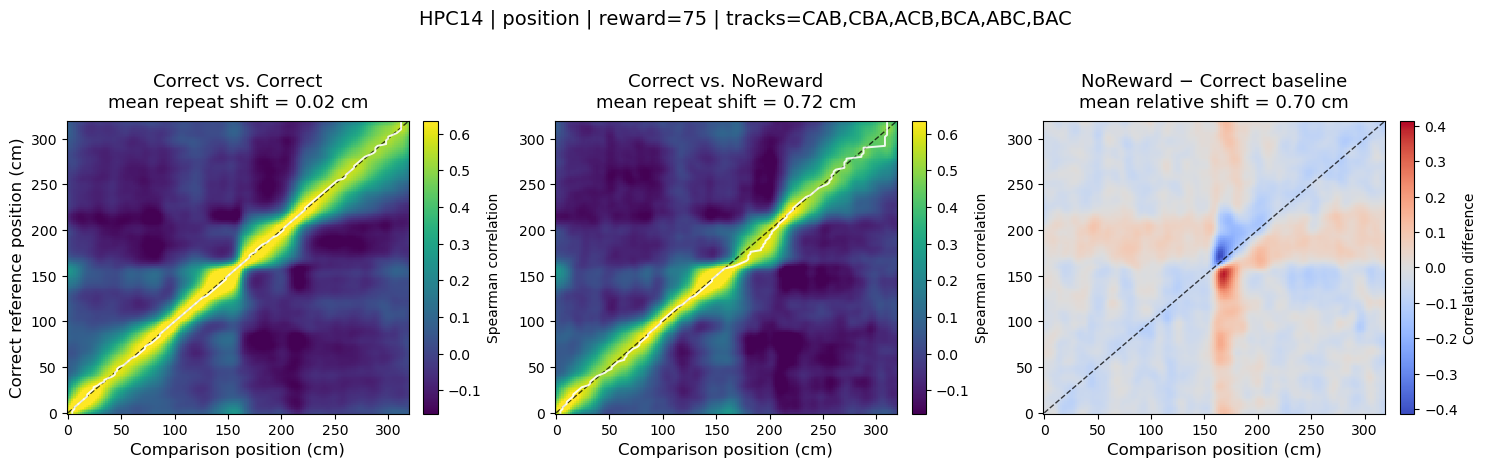

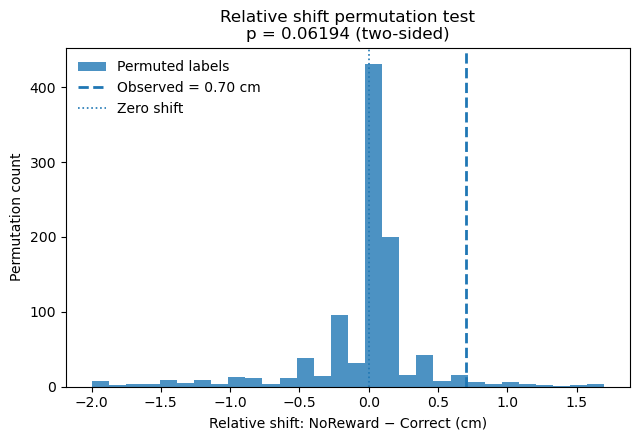

In [12]:
file_path = "../../../data/HPC_2p/screen/HPC14/HPC14_2025-05-24_75_position_screen.pkl"

result, fig, axes, perm_fig, perm_ax = (
    position_generalization_from_file(
        file_path,
        ana_tt=(
            "*",
        ),
        screen_mode="masked",
        source_key="smooth_firing",
        gaussian_sigma=2.0,
        corr_method="spearman",

        n_repeats=100,
        shift_summary="median",
        max_shift_bins=10,

        n_permutations=1000,
        n_repeats_per_permutation=10,
        permutation_alternative="two-sided",

        # 并行计算。
        permutation_n_jobs=8,
        show_permutation_progress=True,
        permutation_batch_size=1,

        random_state=0,
        permutation_random_state=1,

        space_unit=2.0,
        position_offset_bins=0.0,

        show_difference=True,
        show_peak_ridge=True,
        show_permutation_plot=True,
    )
)